## 🌲 04 — Random Forest

**What it does:** Builds many decision trees on random subsets 
of data and takes majority vote — reduces overfitting.  
**Best used when:** You need high accuracy + feature importance.  
**Dataset:** Titanic Survival (via seaborn)  
**Algorithm type:** Supervised → Binary Classification  
**Key concept:** Ensemble learning — many weak trees = one strong model  
**No feature scaling needed!**  
**Model saved as:** `random_forest.pkl`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report)
import pickle
import os

In [18]:
df = sns.load_dataset('titanic')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
df.head()

Shape: (891, 15)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [19]:
# Drop columns not useful for prediction
df = df.drop(['deck', 'embark_town', 'alive', 'who',
              'adult_male', 'class'], axis=1)

# Fill missing age with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing embarked with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Convert sex to numeric
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Convert embarked to numeric
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Drop remaining nulls
df = df.dropna()

print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Shape after cleaning: (891, 9)

Missing values after cleaning:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


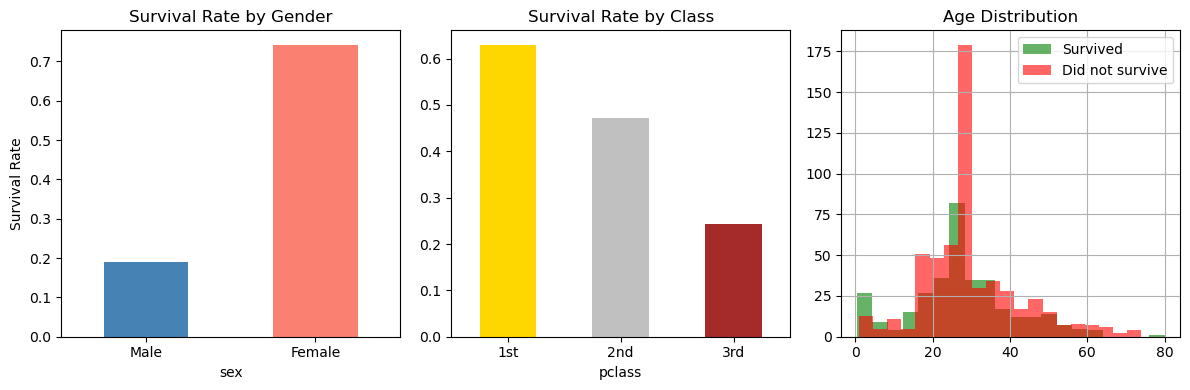

In [20]:
# Survival by gender
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
df.groupby('sex')['survived'].mean().plot(kind='bar',
    color=['steelblue','salmon'])
plt.xticks([0,1], ['Male','Female'], rotation=0)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')

# Survival by class
plt.subplot(1,3,2)
df.groupby('pclass')['survived'].mean().plot(kind='bar',
    color=['gold','silver','brown'])
plt.xticks([0,1,2], ['1st','2nd','3rd'], rotation=0)
plt.title('Survival Rate by Class')

# Age distribution
plt.subplot(1,3,3)
df[df['survived']==1]['age'].hist(alpha=0.6,
    color='green', label='Survived', bins=20)
df[df['survived']==0]['age'].hist(alpha=0.6,
    color='red', label='Did not survive', bins=20)
plt.title('Age Distribution')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# n_estimators = number of trees
model = RandomForestClassifier(n_estimators=100,
                                max_depth=5,
                                random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully ✅")
print(f"Number of trees: {model.n_estimators}")

Model trained successfully ✅
Number of trees: 100


In [22]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Did not survive', 'Survived']))

Accuracy: 0.8212

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.81      0.90      0.86       105
       Survived       0.84      0.70      0.76        74

       accuracy                           0.82       179
      macro avg       0.83      0.80      0.81       179
   weighted avg       0.82      0.82      0.82       179



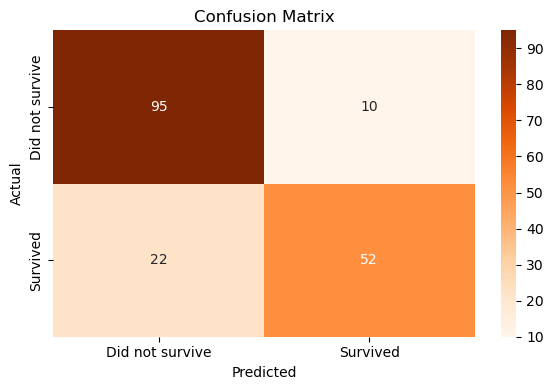

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Did not survive','Survived'],
            yticklabels=['Did not survive','Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

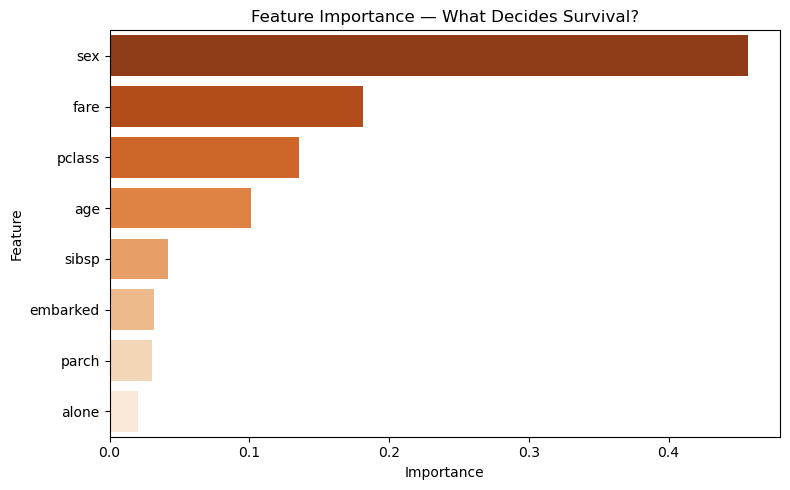

In [25]:
# Feature Importance — Random Forest's superpower
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='Importance',
            y='Feature', palette='Oranges_r', hue = 'Feature', legend=False)
plt.title('Feature Importance — What Decides Survival?')
plt.tight_layout()
plt.show()

In [26]:
with open('random_forest.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved ✅")

Model saved ✅


## ✅ Summary

| Metric | Value |
|--------|-------|
| Accuracy | ~82% |
| Number of Trees | 100 |
| Max Depth | 5 |
| Training Samples | ~712 |
| Testing Samples | ~178 |

**Key difference from Decision Tree:**
- Single Decision Tree → overfits easily
- Random Forest → 100 trees vote together → more robust
- Each tree trains on a random subset of data (bagging)
- Top survival predictors: sex, fare, age, pclass
- Women and 1st class passengers survived more

**Next model → SVM (completely different approach — margins!)**